# Association Rules Mining in MovieLens 1M  

## Step 1 - Exploratory Data Analysis (EDA)

### 1.1 Data Overview
This section provides a first-pass exploratory overview of the MovieLens 1M dataset before association rule mining.

We will inspect:

- Dataset shape
- Data types
- Missing values
- Duplicates
- Descriptive statistics for ratings

In [36]:
from pathlib import Path
import pandas as pd
from mlxtend.frequent_patterns import fpgrowth, association_rules
import matplotlib.pyplot as plt
import numpy as np
import time

import os
if not os.path.exists("results"):
    os.makedirs("results")

output_path = "results"

In [37]:
# Base folder for MovieLens 1M files
DATA_DIR = Path(r"C:\Users\luizf\github\luizbrandi\movies-association\data\ml-1m")

# Column names based on dataset documentation
ratings_cols = ["UserID", "MovieID", "Rating", "Timestamp"]
movies_cols = ["MovieID", "Title", "Genres"]
users_cols = ["UserID", "Gender", "Age", "Occupation", "Zip-code"]

# Load .dat files (separator is '::', so we must use the Python engine)
ratings = pd.read_csv(
    DATA_DIR / "ratings.dat",
    sep="::",
    names=ratings_cols,
    engine="python",
    encoding="latin-1",
)

movies = pd.read_csv(
    DATA_DIR / "movies.dat",
    sep="::",
    names=movies_cols,
    engine="python",
    encoding="latin-1",
)

users = pd.read_csv(
    DATA_DIR / "users.dat",
    sep="::",
    names=users_cols,
    engine="python",
    encoding="latin-1",
)

print("Files loaded successfully.")

Files loaded successfully.


In [38]:
# Put all datasets in a dictionary for compact analysis
datasets = {
    "ratings": ratings,
    "movies": movies,
    "users": users,
}

# 1) Shape overview
shape_overview = pd.DataFrame(
    {
        name: {
            "rows": df.shape[0],
            "columns": df.shape[1],
        }
        for name, df in datasets.items()
    }
).T

print("Dataset shape overview:")
display(shape_overview)

# 2) Data types overview
dtype_overview = pd.DataFrame(
    {
        name: df.dtypes.astype(str)
        for name, df in datasets.items()
    }
)

print("Data types overview:")
display(dtype_overview)

Dataset shape overview:


,rows,columns
ratings,1000209,4
movies,3883,3
users,6040,5


Data types overview:


,ratings,movies,users
Age,NaN,NaN,int64
Gender,NaN,NaN,str
Genres,NaN,str,NaN
MovieID,int64,int64,NaN
Occupation,NaN,NaN,int64
Rating,int64,NaN,NaN
Timestamp,int64,NaN,NaN
Title,NaN,str,NaN
UserID,int64,NaN,int64
Zip-code,NaN,NaN,str


In [39]:
# 3) Missing values overview
missing_overview = []
for name, df in datasets.items():
    missing_count = df.isna().sum()
    missing_pct = (missing_count / len(df) * 100).round(4)
    tmp = pd.DataFrame(
        {
            "dataset": name,
            "column": df.columns,
            "missing_count": missing_count.values,
            "missing_pct": missing_pct.values,
        }
    )
    missing_overview.append(tmp)

missing_overview = pd.concat(missing_overview, ignore_index=True)

print("Missing values by column:")
display(missing_overview.sort_values(["dataset", "missing_count"], ascending=[True, False]))

# 4) Duplicate overview
duplicate_overview = pd.DataFrame(
    {
        "dataset": ["ratings", "movies", "users"],
        "full_row_duplicates": [
            ratings.duplicated().sum(),
            movies.duplicated().sum(),
            users.duplicated().sum(),
        ],
        "key_duplicates": [
            ratings.duplicated(subset=["UserID", "MovieID", "Timestamp"]).sum(),
            movies.duplicated(subset=["MovieID"]).sum(),
            users.duplicated(subset=["UserID"]).sum(),
        ],
    }
)

print("Duplicate checks:")
display(duplicate_overview)

Missing values by column:


,dataset,column,missing_count,missing_pct
4,movies,MovieID,0,0.0
5,movies,Title,0,0.0
6,movies,Genres,0,0.0
0,ratings,UserID,0,0.0
1,ratings,MovieID,0,0.0
2,ratings,Rating,0,0.0
3,ratings,Timestamp,0,0.0
7,users,UserID,0,0.0
8,users,Gender,0,0.0
9,users,Age,0,0.0


Duplicate checks:


,dataset,full_row_duplicates,key_duplicates
0,ratings,0,0
1,movies,0,0
2,users,0,0


In [40]:
# 5) Descriptive statistics for ratings
print("Rating distribution:")
display(ratings["Rating"].value_counts().sort_index().rename("count").to_frame())

print("Rating descriptive statistics:")
display(ratings["Rating"].describe())

print("Unique users in ratings:", ratings["UserID"].nunique())
print("Unique movies in ratings:", ratings["MovieID"].nunique())
print("Total ratings:", len(ratings))

Rating distribution:


,count
Rating,
1,56174
2,107557
3,261197
4,348971
5,226310


Rating descriptive statistics:


count    1.000209e+06
mean     3.581564e+00
std      1.117102e+00
min      1.000000e+00
25%      3.000000e+00
50%      4.000000e+00
75%      4.000000e+00
max      5.000000e+00
Name: Rating, dtype: float64

Unique users in ratings: 6040
Unique movies in ratings: 3706
Total ratings: 1000209


### 1.2 Rating distribution, user activity, and long-tail behavior

Next, we inspect the distribution of ratings, how many ratings each user and each movie receives, and whether the movie popularity follows a long-tail pattern.

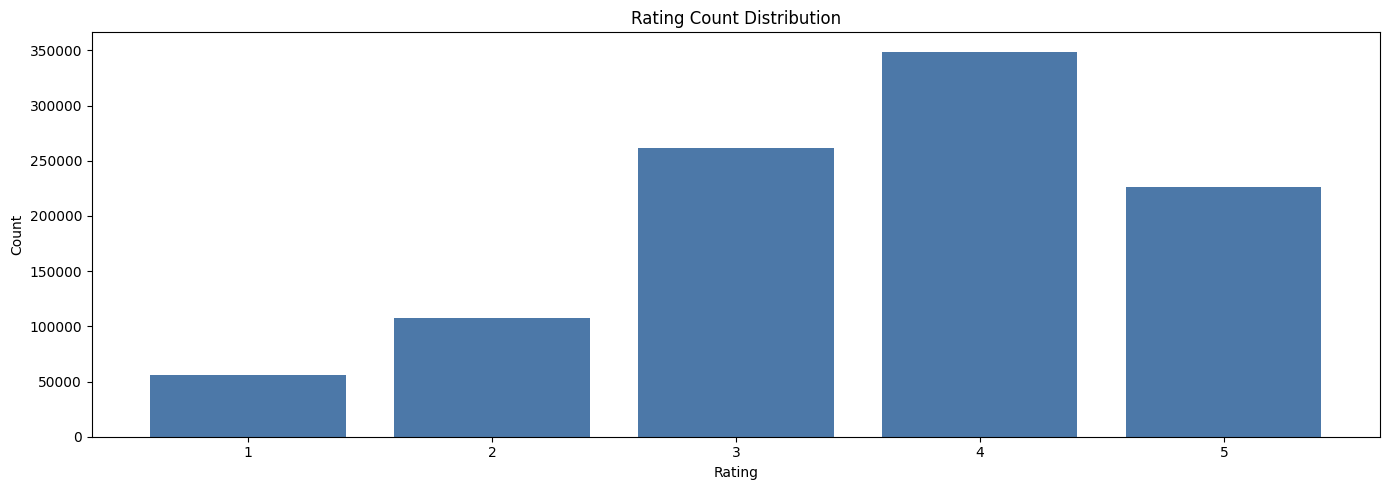

Rating distribution summary:


,count,share_pct
Rating,,
1,56174,5.62
2,107557,10.75
3,261197,26.11
4,348971,34.89
5,226310,22.63


In [41]:
# Rating distribution
rating_counts = ratings["Rating"].value_counts().sort_index()

fig, axes = plt.subplots(1, 1, figsize=(14, 5))

axes.bar(rating_counts.index.astype(str), rating_counts.values, color="#4C78A8")
axes.set_title("Rating Count Distribution")
axes.set_xlabel("Rating")
axes.set_ylabel("Count")
plt.tight_layout()
plt.show()

rating_share = (rating_counts / len(ratings) * 100).round(2)
rating_summary = pd.DataFrame({"count": rating_counts, "share_pct": rating_share})

print("Rating distribution summary:")
display(rating_summary)

The distribution shows that the majority of ratings are clustered around the middle (3 and 4), that corresponds to 61%, with fewer ratings at the extremes (1 and 5). This suggests that users tend to give moderate ratings more often than extreme ones.

On the dataset MovieLens we doesn't have the label **"watched"**, we only have ratings, so we will consider that a user **"watched and liked"** if they have a **rating >= 4**. This represents 57.52% of all ratings, indicating that more than half of the ratings are positive (4 or 5), while the rest are neutral (3) that can adds noise to the analysis or negative (1 and 2). This suggests that users tend to rate movies they liked more frequently than those they disliked.

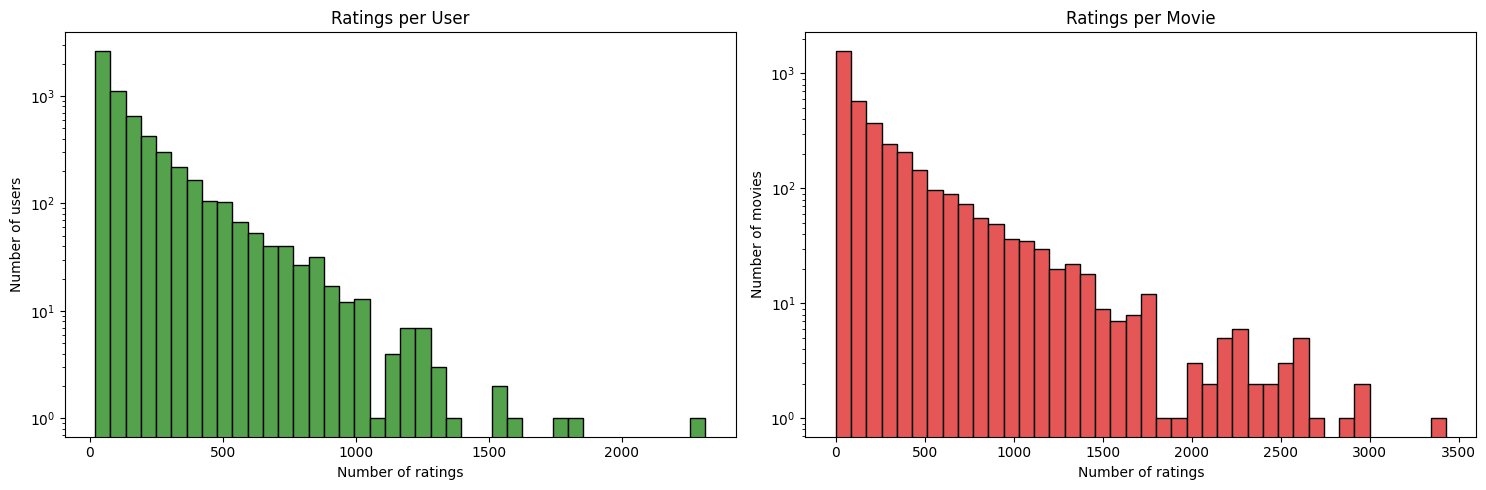

Activity summary:


,metric,mean,median,std,min,max
0,ratings per user,165.597517,96.0,192.747029,20,2314
1,ratings per movie,269.889099,123.5,384.047838,1,3428


User activity percentiles:


,ratings_per_user
0.25,44.00
0.50,96.00
0.75,208.00
0.90,400.00
0.95,556.00
0.99,906.66


Movie activity percentiles:


,ratings_per_movie
0.25,33.0
0.50,123.5
0.75,350.0
0.90,729.5
0.95,1051.5
0.99,1784.9


In [42]:
# User and movie activity distributions
ratings_per_user = ratings.groupby("UserID").size()
ratings_per_movie = ratings.groupby("MovieID").size()

activity_summary = pd.DataFrame(
    {
        "metric": ["ratings per user", "ratings per movie"],
        "mean": [ratings_per_user.mean(), ratings_per_movie.mean()],
        "median": [ratings_per_user.median(), ratings_per_movie.median()],
        "std": [ratings_per_user.std(), ratings_per_movie.std()],
        "min": [ratings_per_user.min(), ratings_per_movie.min()],
        "max": [ratings_per_user.max(), ratings_per_movie.max()],
    }
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(ratings_per_user, bins=40, color="#54A24B", edgecolor="black")
axes[0].set_title("Ratings per User")
axes[0].set_xlabel("Number of ratings")
axes[0].set_ylabel("Number of users")
axes[0].set_yscale("log")

axes[1].hist(ratings_per_movie, bins=40, color="#E45756", edgecolor="black")
axes[1].set_title("Ratings per Movie")
axes[1].set_xlabel("Number of ratings")
axes[1].set_ylabel("Number of movies")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

print("Activity summary:")
display(activity_summary)

print("User activity percentiles:")
display(ratings_per_user.quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).to_frame(name="ratings_per_user"))

print("Movie activity percentiles:")
display(ratings_per_movie.quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).to_frame(name="ratings_per_movie"))

These results show that while the average user rates around 165 movies, the median is only 96, indicating a skewed distribution where **a small number of users rate a large number of movies**. 

Similarly, while the average movie has around 270 ratings, the median is only 123.5, suggesting that **a few popular movies receive a disproportionate number of ratings**. 

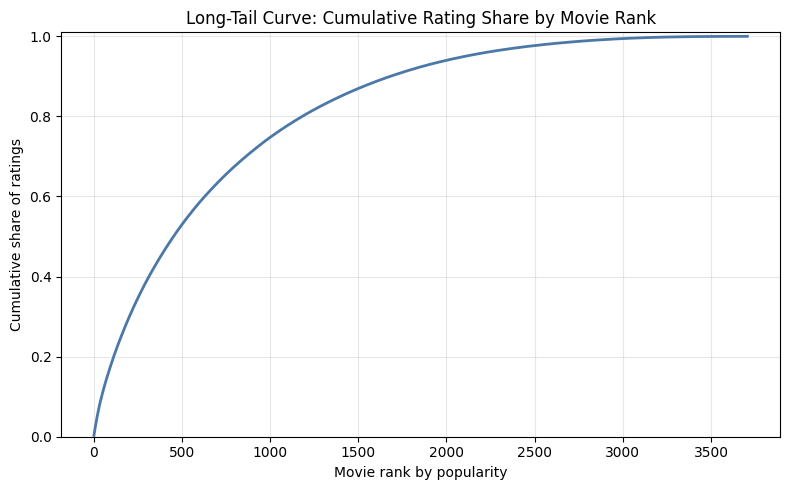

Long-tail summary:


,threshold,movies_with_at_most_threshold_ratings,share_of_movies_pct
0,1,114,3.076093
1,5,329,8.877496
2,10,473,12.763087
3,50,1207,32.568807
4,100,1700,45.871560
5,150,2024,54.614139


In [43]:
# Long-tail analysis for movies
movie_ratings_sorted = ratings_per_movie.sort_values(ascending=False)
movie_rank = range(1, len(movie_ratings_sorted) + 1)
movie_cumulative_share = movie_ratings_sorted.cumsum() / movie_ratings_sorted.sum()

thresholds = [1, 5, 10, 50, 100, 150]
long_tail_summary = pd.DataFrame(
    {
        "threshold": thresholds,
        "movies_with_at_most_threshold_ratings": [
            (ratings_per_movie <= threshold).sum() for threshold in thresholds
        ],
        "share_of_movies_pct": [
            (ratings_per_movie <= threshold).mean() * 100 for threshold in thresholds
        ],
    }
)

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

ax.plot(movie_rank, movie_cumulative_share, color="#4C78A8", linewidth=2)
ax.set_title("Long-Tail Curve: Cumulative Rating Share by Movie Rank")
ax.set_xlabel("Movie rank by popularity")
ax.set_ylabel("Cumulative share of ratings")
ax.set_ylim(0, 1.01)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Long-tail summary:")
display(long_tail_summary)

The distribuition of movies popularity revealed a strong long-tail pattern. Aproximately 45.8% of movies have received 100 or fewer ratings, this reveals that most movies have a small number of ratings, while a few popular movies receive a large share of ratings.

### 1.3 Most reviewed movies and top-rated movies

Now we will analyze the most reviewed movies and the top-rated movies, considering only those with a minimum number of 50 ratings to ensure reliability and reduce noise.

In [44]:

movie_stats = (
    ratings.groupby("MovieID")["Rating"]
    .agg(rating_count="count", rating_mean="mean")
    .reset_index()
    .merge(movies[["MovieID", "Title"]], on="MovieID", how="left")
    .loc[:, ["MovieID", "Title", "rating_count", "rating_mean"]]
)

# Top-20 by number of ratings
top20_by_count = (
    movie_stats.sort_values(["rating_count", "rating_mean"], ascending=[False, False])
    .head(20)
    .reset_index(drop=True)
)

# Top-20 by average rating (with a minimum number of ratings to reduce noise)
min_ratings_for_mean = 50
top20_by_mean = (
    movie_stats[movie_stats["rating_count"] >= min_ratings_for_mean]
    .sort_values(["rating_mean", "rating_count"], ascending=[False, False])
    .head(20)
    .reset_index(drop=True)
)

# Round mean rating for presentation
top20_by_count["rating_mean"] = top20_by_count["rating_mean"].round(3)
top20_by_mean["rating_mean"] = top20_by_mean["rating_mean"].round(3)

print("Top-20 movies by number of ratings:")
display(top20_by_count)

print(f"Top-20 movies by average rating (only movies with at least {min_ratings_for_mean} ratings):")
display(top20_by_mean)

# Popularity bias diagnostics
popularity_share_top20 = top20_by_count["rating_count"].sum() / ratings.shape[0]
print(f"Share of all ratings concentrated in top-20 most-rated movies: {popularity_share_top20:.2%}")

Top-20 movies by number of ratings:


,MovieID,Title,rating_count,rating_mean
0,2858,American Beauty (1999),3428,4.317
1,260,Star Wars: Episode IV - A New Hope (1977),2991,4.454
2,1196,Star Wars: Episode V - The Empire Strikes Back...,2990,4.293
3,1210,Star Wars: Episode VI - Return of the Jedi (1983),2883,4.023
4,480,Jurassic Park (1993),2672,3.764
5,2028,Saving Private Ryan (1998),2653,4.337
6,589,Terminator 2: Judgment Day (1991),2649,4.059
7,2571,"Matrix, The (1999)",2590,4.316
8,1270,Back to the Future (1985),2583,3.990
9,593,"Silence of the Lambs, The (1991)",2578,4.352


Top-20 movies by average rating (only movies with at least 50 ratings):


,MovieID,Title,rating_count,rating_mean
0,2905,Sanjuro (1962),69,4.609
1,2019,Seven Samurai (The Magnificent Seven) (Shichin...,628,4.561
2,318,"Shawshank Redemption, The (1994)",2227,4.555
3,858,"Godfather, The (1972)",2223,4.525
4,745,"Close Shave, A (1995)",657,4.521
5,50,"Usual Suspects, The (1995)",1783,4.517
6,527,Schindler's List (1993),2304,4.510
7,1148,"Wrong Trousers, The (1993)",882,4.508
8,922,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),470,4.491
9,1198,Raiders of the Lost Ark (1981),2514,4.478


Share of all ratings concentrated in top-20 most-rated movies: 5.20%


The ranking by `rating_count` emphasizes mainstream movies that naturally receive more exposure. If we mine association rules directly on raw interactions, very popular titles tend to dominate the discovered patterns.

Key implications:

- Rules may over-represent blockbusters and under-represent niche movies.
- High support can reflect popularity, not necessarily strong item affinity.
- Average rating alone can also be biased when computed from few ratings (hence the minimum-count filter).

### 1.4 User profile

In this subsection, we analyze how many movies each user rated to distinguish very active users from sporadic users.

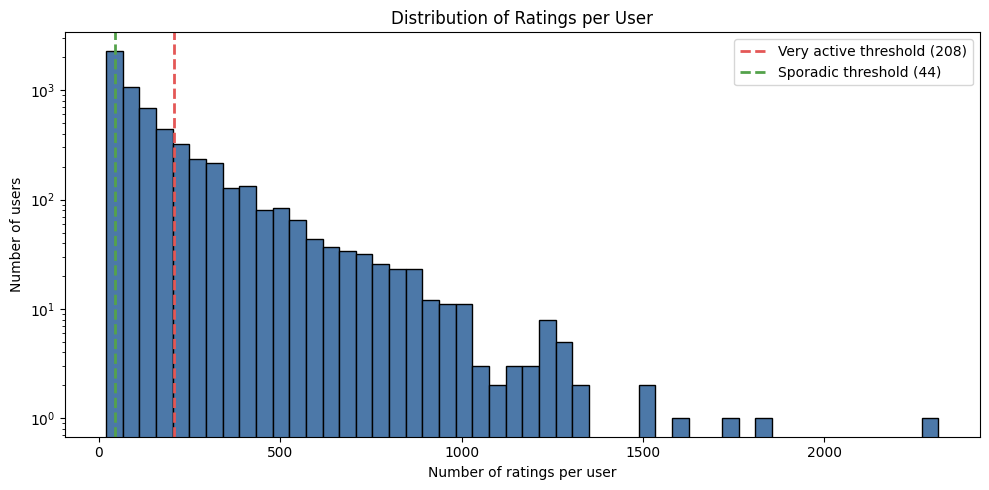

User profile summary:


,metric,value
0,users,6040.000000
1,avg_ratings_per_user,165.597517
2,median_ratings_per_user,96.000000
3,std_ratings_per_user,192.747029
4,min_ratings_per_user,20.000000
5,max_ratings_per_user,2314.000000


User activity segments:


,segment,definition,users_count
0,Very active,Users with more than 208 ratings,1503
1,Typical,Users between 44 and 208 ratings,3055
2,Sporadic,Users with fewer than 44 ratings,1482


Top 10 most active users:


,ratings_count
UserID,
4169,2314
1680,1850
4277,1743
1941,1595
1181,1521
889,1518
3618,1344
2063,1323
1150,1302


Top 10 most sporadic users:


,ratings_count
UserID,
2128,20
4547,20
4527,20
4525,20
4419,20
4398,20
4393,20
932,20
4365,20


In [45]:
# 1.4 User profile
ratings_per_user = ratings.groupby("UserID").size().rename("ratings_count")

user_profile_summary = pd.DataFrame(
    {
        "metric": ["users", "avg_ratings_per_user", "median_ratings_per_user", "std_ratings_per_user", "min_ratings_per_user", "max_ratings_per_user"],
        "value": [
            ratings_per_user.shape[0],
            ratings_per_user.mean(),
            ratings_per_user.median(),
            ratings_per_user.std(),
            ratings_per_user.min(),
            ratings_per_user.max(),
        ],
    }
)

# Percentile-based thresholds to classify users
active_threshold = ratings_per_user.quantile(0.75)
esporadic_threshold = ratings_per_user.quantile(0.25)

user_segments = pd.DataFrame(
    {
        "segment": ["Very active", "Typical", "Sporadic"],
        "definition": [
            f"Users with more than {active_threshold:.0f} ratings",
            f"Users between {esporadic_threshold:.0f} and {active_threshold:.0f} ratings",
            f"Users with fewer than {esporadic_threshold:.0f} ratings",
        ],
        "users_count": [
            (ratings_per_user > active_threshold).sum(),
            ((ratings_per_user >= esporadic_threshold) & (ratings_per_user <= active_threshold)).sum(),
            (ratings_per_user < esporadic_threshold).sum(),
        ],
    }
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ratings_per_user, bins=50, color="#4C78A8", edgecolor="black")
ax.axvline(active_threshold, color="#E45756", linestyle="--", linewidth=2, label=f"Very active threshold ({active_threshold:.0f})")
ax.axvline(esporadic_threshold, color="#54A24B", linestyle="--", linewidth=2, label=f"Sporadic threshold ({esporadic_threshold:.0f})")
ax.set_title("Distribution of Ratings per User")
ax.set_xlabel("Number of ratings per user")
ax.set_ylabel("Number of users")
ax.set_yscale("log")
ax.legend()
plt.tight_layout()
plt.show()

print("User profile summary:")
display(user_profile_summary)

print("User activity segments:")
display(user_segments)

print("Top 10 most active users:")
display(ratings_per_user.sort_values(ascending=False).head(10).to_frame())

print("Top 10 most sporadic users:")
display(ratings_per_user.sort_values(ascending=True).head(10).to_frame())

The user activity profile shows a highly skewed distribution of ratings per user. Using quartile-based segmentation, 1,503 users are classified as very active, with more than 208 ratings, while 1,482 users are sporadic, with fewer than 44 ratings. The most active user has 2,314 ratings, which is far above the rest of the population, confirming the presence of a strong long-tail pattern in user behavior.

### 1.5 Genre analysis

Here we analyze the distribution of movies by genre, as well as which genres concentrate more ratings and higher average scores.

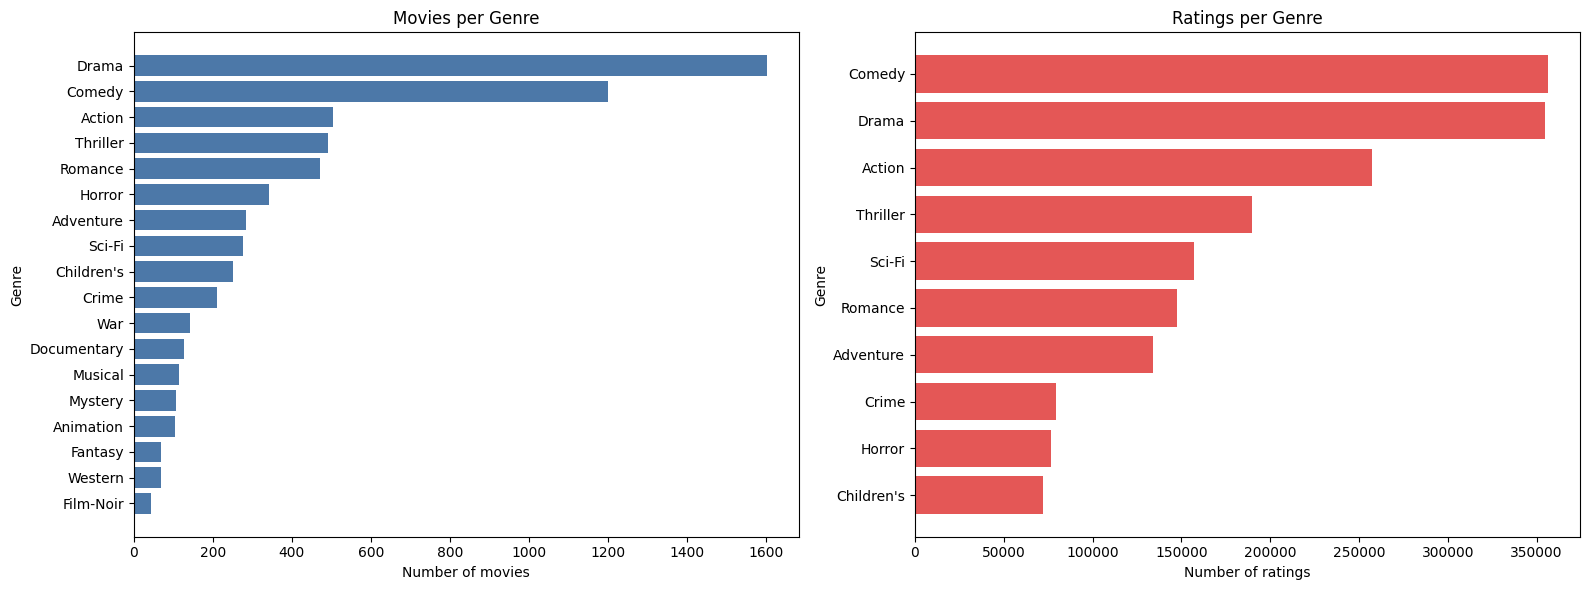

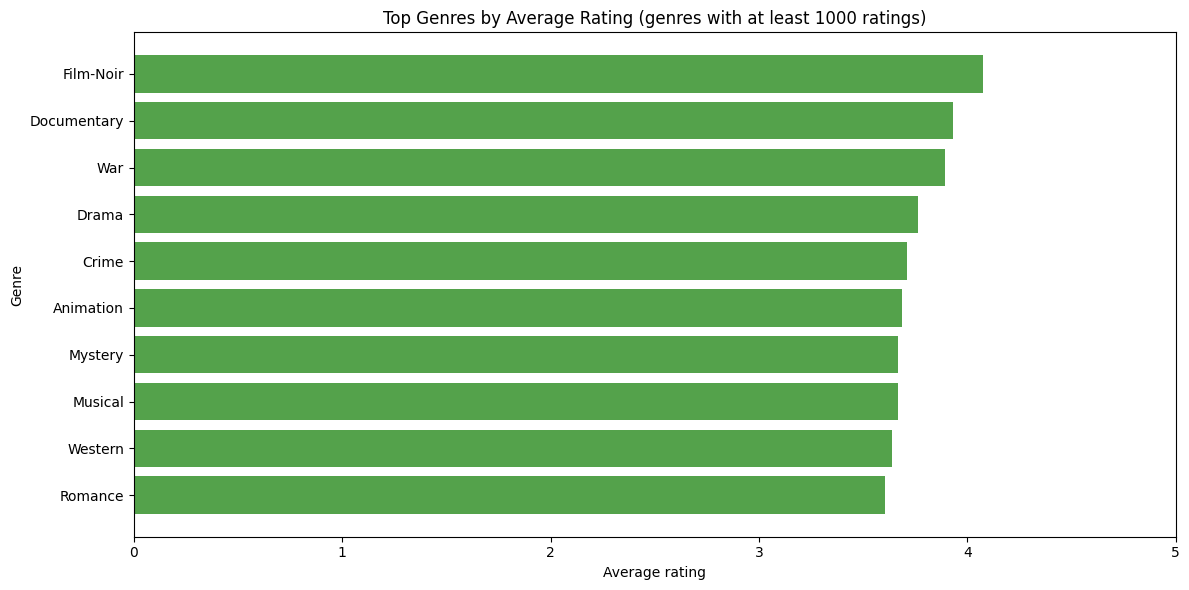

Genre summary:


,movie_count,rating_count,avg_rating,median_rating
Genre,,,,
Comedy,1200,356617,3.522,4.0
Drama,1603,354639,3.766,4.0
Action,503,257465,3.491,4.0
Thriller,492,189687,3.570,4.0
Sci-Fi,276,157296,3.467,4.0
Romance,471,147535,3.607,4.0
Adventure,283,133955,3.477,4.0
Crime,211,79551,3.709,4.0
Horror,343,76390,3.215,3.0


Top 10 genres by number of ratings:


,movie_count,rating_count,avg_rating,median_rating
Genre,,,,
Comedy,1200,356617,3.522,4.0
Drama,1603,354639,3.766,4.0
Action,503,257465,3.491,4.0
Thriller,492,189687,3.570,4.0
Sci-Fi,276,157296,3.467,4.0
Romance,471,147535,3.607,4.0
Adventure,283,133955,3.477,4.0
Crime,211,79551,3.709,4.0
Horror,343,76390,3.215,3.0


Top 10 genres by average rating (only genres with at least 1000 ratings):


,movie_count,rating_count,avg_rating,median_rating
Genre,,,,
Film-Noir,44,18261,4.075,4.0
Documentary,127,7927,3.933,4.0
War,143,68529,3.893,4.0
Drama,1603,354639,3.766,4.0
Crime,211,79551,3.709,4.0
Animation,105,43293,3.685,4.0
Mystery,106,40180,3.668,4.0
Musical,114,41534,3.666,4.0
Western,68,20684,3.638,4.0


In [46]:
# 1.5 Genre analysis
# MovieLens genres are multi-label, so each movie can belong to multiple genres.
movie_genres = (
    movies.loc[:, ["MovieID", "Title", "Genres"]]
    .assign(Genre=lambda frame: frame["Genres"].str.split("|"))
    .explode("Genre")
)

movies_with_ratings = movie_genres.merge(
    ratings.loc[:, ["MovieID", "Rating"]],
    on="MovieID",
    how="left",
)

genre_summary = (
    movies_with_ratings.groupby("Genre")
    .agg(
        movie_count=("MovieID", "nunique"),
        rating_count=("Rating", "size"),
        avg_rating=("Rating", "mean"),
        median_rating=("Rating", "median"),
    )
    .sort_values("rating_count", ascending=False)
)

genre_summary["avg_rating"] = genre_summary["avg_rating"].round(3)
genre_summary["median_rating"] = genre_summary["median_rating"].round(3)

# Top genres by rating volume and by average rating
min_genre_ratings = 1000
top_genres_by_count = genre_summary.head(10)
top_genres_by_rating = genre_summary[genre_summary["rating_count"] >= min_genre_ratings].sort_values(
    ["avg_rating", "rating_count"], ascending=[False, False]
).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_movie_counts = genre_summary.sort_values("movie_count", ascending=True)
axes[0].barh(top_movie_counts.index, top_movie_counts["movie_count"], color="#4C78A8")
axes[0].set_title("Movies per Genre")
axes[0].set_xlabel("Number of movies")
axes[0].set_ylabel("Genre")

axes[1].barh(top_genres_by_count.sort_values("rating_count").index, top_genres_by_count.sort_values("rating_count")["rating_count"], color="#E45756")
axes[1].set_title("Ratings per Genre")
axes[1].set_xlabel("Number of ratings")
axes[1].set_ylabel("Genre")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_genres_by_rating.sort_values("avg_rating").index, top_genres_by_rating.sort_values("avg_rating")["avg_rating"], color="#54A24B")
ax.set_title(f"Top Genres by Average Rating (genres with at least {min_genre_ratings} ratings)")
ax.set_xlabel("Average rating")
ax.set_ylabel("Genre")
ax.set_xlim(0, 5)
plt.tight_layout()
plt.show()

print("Genre summary:")
display(genre_summary)

print("Top 10 genres by number of ratings:")
display(top_genres_by_count)

print(f"Top 10 genres by average rating (only genres with at least {min_genre_ratings} ratings):")
display(top_genres_by_rating)

The genre distribution is multi-label, so a single movie can contribute to multiple genres. As a result, genres with broad appeal, such as Drama, Comedy, or Action, usually accumulate more ratings because they appear in many popular titles. In contrast, genres with fewer movies may still achieve high average ratings, but these averages should be interpreted carefully and preferably only for genres with a reasonable number of ratings. 

### 1.6 User × Movie matrix sparsity

In this subsection, we compute and interpret the sparsity of the user×movie matrix and relate it to the choice of `min_support` for association rule mining. We also reaffirm the binary definition `watched_and_liked = (Rating >= 4)`.

In [47]:
n_users = ratings["UserID"].nunique()
n_movies = ratings["MovieID"].nunique()

# Matrix size and explicit-feedback density (all observed ratings)
matrix_size = n_users * n_movies
observed_interactions = ratings.shape[0]
density_all_ratings = observed_interactions / matrix_size
sparsity_all_ratings = 1 - density_all_ratings

# Binary target for association mining: watched and liked (rating >= 4)
liked_ratings = ratings[ratings["Rating"] >= 4].copy()
liked_interactions = liked_ratings.shape[0]
liked_share_pct = liked_interactions / observed_interactions * 100

density_liked = liked_interactions / matrix_size
sparsity_liked = 1 - density_liked

# Practical support anchors: minimum number of users supporting an itemset
min_user_support_targets = [10, 20, 30, 50, 100]
support_anchor_table = pd.DataFrame(
    {
        "min_users": min_user_support_targets,
        "min_support": [target / n_users for target in min_user_support_targets],
    }
)
support_anchor_table["min_support"] = support_anchor_table["min_support"].round(6)

sparsity_summary = pd.DataFrame(
    {
        "metric": [
            "n_users",
            "n_movies",
            "matrix_size_users_x_movies",
            "observed_ratings",
            "density_all_ratings",
            "sparsity_all_ratings",
            "liked_interactions_rating_ge_4",
            "liked_share_pct",
            "density_liked_ge_4",
            "sparsity_liked_ge_4",
        ],
        "value": [
            n_users,
            n_movies,
            matrix_size,
            observed_interactions,
            density_all_ratings,
            sparsity_all_ratings,
            liked_interactions,
            liked_share_pct,
            density_liked,
            sparsity_liked,
        ],
    }
)

print("Sparsity summary:")
display(sparsity_summary)

print("Support anchors based on minimum number of users:")
display(support_anchor_table)

Sparsity summary:


,metric,value
0,n_users,6.040000e+03
1,n_movies,3.706000e+03
2,matrix_size_users_x_movies,2.238424e+07
3,observed_ratings,1.000209e+06
4,density_all_ratings,4.468363e-02
5,sparsity_all_ratings,9.553164e-01
6,liked_interactions_rating_ge_4,5.752810e+05
7,liked_share_pct,5.751608e+01
8,density_liked_ge_4,2.570027e-02
9,sparsity_liked_ge_4,9.742997e-01


Support anchors based on minimum number of users:


,min_users,min_support
0,10,0.001656
1,20,0.003311
2,30,0.004967
3,50,0.008278
4,100,0.016556


The user×movie matrix is highly sparse, which is expected in recommender-system datasets: each user rates only a small subset of all available movies. When the matrix is converted to a binary format using `Rating >= 4` (watched and liked), sparsity increases further because neutral (`3`) and negative (`1`, `2`) ratings are excluded.

This supports the choice of defining positive interactions as `>= 4`: these ratings represent 57.52% of all interactions, so the positive signal is still large enough for mining while reducing noise from neutral/negative feedback.

Because of high sparsity, very large `min_support` values will remove most potentially useful rules, especially from long-tail movies. A practical strategy is to start from support anchors tied to absolute user counts (for example, rules supported by at least 20–50 users) and then refine using quality metrics such as confidence and lift.

## Step 2 - Association Rule Mining

### 2.1 Transactional transformation

In this step, each user is converted into a transaction, and the items are the movies that the user watched and liked (`Rating >= 4`).

In [48]:
# 2.1 Transactional transformation
# We use only positive interactions (Rating >= 4) to build transactions.
liked_ratings = ratings.loc[ratings["Rating"] >= 4, ["UserID", "MovieID"]].copy()
liked_ratings["MovieID"] = liked_ratings["MovieID"].astype("int32")

# Remove duplicate user-item interactions if any
liked_ratings = liked_ratings.drop_duplicates()

# Transaction list: one list of MovieIDs per user
transactions = (
    liked_ratings.groupby("UserID", sort=False)["MovieID"]
    .apply(list)
    .reset_index(name="items")
)

print("Transactions preview (MovieIDs):")
display(transactions.head())

print("Transformation summary:")
transformation_summary = pd.DataFrame(
    {
        "metric": [
            "users_with_at_least_one_liked_movie",
            "transactions",
            "unique_items",
            "liked_interactions",
        ],
        "value": [
            transactions.shape[0],
            transactions.shape[0],
            liked_ratings["MovieID"].nunique(),
            len(liked_ratings),
        ],
    }
)
display(transformation_summary)

# Keep a compact list of items per transaction for the mining step
transaction_lists = transactions["items"].tolist()

Transactions preview (MovieIDs):


,UserID,items
0,1,"[1193, 3408, 2355, 1287, 2804, 594, 919, 595, ..."
1,2,"[1357, 3068, 1537, 2194, 648, 2268, 3468, 1210..."
2,3,"[3421, 1394, 104, 2735, 1210, 1079, 1615, 1291..."
3,4,"[3468, 2951, 1214, 1036, 260, 2028, 480, 1198,..."
4,5,"[2987, 2333, 1175, 2337, 1535, 1392, 866, 2770..."


Transformation summary:


,metric,value
0,users_with_at_least_one_liked_movie,6038
1,transactions,6038
2,unique_items,3533
3,liked_interactions,575281


### 2.2 Algorithm choice and justification

Given the dataset size and sparsity observed in EDA, **FP-Growth** is the recommended algorithm for frequent itemset mining.

Why FP-Growth is a better fit here:

- We have a relatively large transactional space (6,040 users and 3,706 movies).
- The user×movie matrix is highly sparse (`sparsity_all_ratings ≈ 95.53%` and `sparsity_liked_ge_4 ≈ 97.43%`).
- Apriori generates many candidate itemsets and repeatedly scans the database, which becomes expensive in sparse, high-dimensional settings.
- FP-Growth compresses transactions into an FP-tree and avoids explicit candidate generation, usually providing better time and memory efficiency.

Apriori can still be useful as a baseline on restricted subsets or with higher `min_support`, but FP-Growth is more appropriate as the main method for this project.

### 4.3 Hyperparameter definition

Based on EDA and computational constraints, we define the initial hyperparameters for FP-Growth and association rules as follows:

- **Minimum support (`min_support`) = 0.03**
- **Minimum confidence (`min_confidence`) = 0.25**
- **Minimum lift (`min_lift`) = 1.20**
- **Maximum itemset size (`max_len`) = 3**
- **Minimum users per movie (`min_item_users`) = 100**
- **Maximum items per transaction (`max_items_per_transaction`) = 200**

Justification from EDA and scalability constraints:

1. The matrix is highly sparse (`sparsity_all_ratings ≈ 95.53%`, `sparsity_liked_ge_4 ≈ 97.43%`), so support/quality thresholds are needed to avoid noisy and weak rules.
2. To reduce combinatorial explosion, `min_support` was increased to `0.03`, focusing on more representative co-occurrences.
3. Movies with fewer than 100 interactions were removed because users have a high number of interactions (mean above ~95 items per transaction, with extreme cases above ~1400 items), which amplifies the combinatorial search space in FP-Growth.
4. Based on user segmentation, most users have up to 208 interactions; users above this limit are outliers in activity volume. To preserve typical behavior while controlling the impact of extremely active users, each transaction is capped at 200 items.
5. `max_len = 3` limits itemset size to control memory/time complexity while keeping interpretable multi-item patterns.

In [49]:
# 4.3 Hyperparameter values derived from EDA and scalability constraints
chosen_min_support = 0.03
chosen_min_confidence = 0.25
chosen_min_lift = 1.20
chosen_max_len = 3  # limitar geração até 3-itemsets
chosen_min_item_users = 100  # remover filmes com menos de 100 interações
chosen_max_items_per_transaction = 200  # limitar tamanho de transação

min_users_for_support = int(round(chosen_min_support * n_users))

hyperparameter_summary = pd.DataFrame(
    {
        "hyperparameter": [
            "min_support",
            "min_confidence",
            "min_lift",
            "max_len",
            "min_item_users",
            "max_items_per_transaction",
        ],
        "value": [
            chosen_min_support,
            chosen_min_confidence,
            chosen_min_lift,
            chosen_max_len,
            chosen_min_item_users,
            chosen_max_items_per_transaction,
        ],
    }
)

support_scale = pd.DataFrame(
    {
        "support": [0.01, 0.02, 0.03, 0.05],
    }
)
support_scale["approx_min_users"] = (support_scale["support"] * n_users).round().astype(int)

print("Chosen hyperparameters:")
display(hyperparameter_summary)

print(f"With min_support={chosen_min_support:.3f}, an itemset must appear in at least ~{min_users_for_support} users.")
print(f"Maximum itemset size (max_len): {chosen_max_len}")
print(f"Minimum users per movie (min_item_users): {chosen_min_item_users}")
print(f"Maximum items per transaction: {chosen_max_items_per_transaction}")

print("Support sensitivity reference:")
display(support_scale)

Chosen hyperparameters:


,hyperparameter,value
0,min_support,0.03
1,min_confidence,0.25
2,min_lift,1.20
3,max_len,3.00
4,min_item_users,100.00
5,max_items_per_transaction,200.00


With min_support=0.030, an itemset must appear in at least ~181 users.
Maximum itemset size (max_len): 3
Minimum users per movie (min_item_users): 100
Maximum items per transaction: 200
Support sensitivity reference:


,support,approx_min_users
0,0.01,60
1,0.02,121
2,0.03,181
3,0.05,302


### 2.3 Rule extraction and filtering

In this subsection, we extract association rules with FP-Growth, keep only rules with `lift > 1`, rank them by relevance, and display the Top-20 rules.

In [50]:
# 2.3 Extract and filter association rules (FP-Growth)
import math

try:
    from mlxtend.frequent_patterns import fpgrowth, association_rules
    from mlxtend.preprocessing import TransactionEncoder
except Exception as exc:
    raise ImportError(
        "mlxtend is required for FP-Growth. Install it before running this cell."
    ) from exc

# Use hyperparameters from 4.3 if already defined; otherwise use defaults
min_support = chosen_min_support if "chosen_min_support" in globals() else 0.03
min_confidence = chosen_min_confidence if "chosen_min_confidence" in globals() else 0.25
min_lift = chosen_min_lift if "chosen_min_lift" in globals() else 1.20
max_len = chosen_max_len if "chosen_max_len" in globals() else 3
min_item_users = chosen_min_item_users if "chosen_min_item_users" in globals() else 100
max_items_per_transaction = (
    chosen_max_items_per_transaction if "chosen_max_items_per_transaction" in globals() else 200
)

# Pre-filter items with low frequency
liked_base = (
    liked_ratings[["UserID", "MovieID"]].drop_duplicates()
    if "liked_ratings" in globals()
    else ratings.loc[ratings["Rating"] >= 4, ["UserID", "MovieID"]].drop_duplicates()
)

item_freq = liked_base["MovieID"].value_counts()
eligible_items = set(item_freq[item_freq >= min_item_users].index.tolist())
liked_filtered = liked_base[liked_base["MovieID"].isin(eligible_items)].copy()

# Cap number of items per transaction to avoid combinatorial explosion
liked_filtered["item_freq"] = liked_filtered["MovieID"].map(item_freq)
liked_filtered = liked_filtered.sort_values(
    ["UserID", "item_freq", "MovieID"],
    ascending=[True, False, True],
)

transaction_sizes_before_cap = liked_filtered.groupby("UserID")["MovieID"].size()
users_truncated = int((transaction_sizes_before_cap > max_items_per_transaction).sum())

transactions_filtered = (
    liked_filtered.groupby("UserID", sort=False)["MovieID"]
    .apply(lambda s: s.head(max_items_per_transaction).tolist())
    .tolist()
)

# Build a sparse one-hot encoded matrix from the filtered transaction lists
te = TransactionEncoder()
te_array = te.fit(transactions_filtered).transform(transactions_filtered, sparse=True)
encoded_matrix = pd.DataFrame.sparse.from_spmatrix(te_array, columns=te.columns_)
encoded_matrix = encoded_matrix.astype(bool)

In [51]:
print("Transactions after filtering:", len(transactions_filtered))
print("Avg items per transaction (after cap):", np.mean([len(t) for t in transactions_filtered]))
print("Max items in a transaction (after cap):", max(len(t) for t in transactions_filtered))
print("Users truncated by max_items_per_transaction:", users_truncated)
print("Number of unique items after item filter:", len(te.columns_))

Transactions after filtering: 6037
Avg items per transaction (after cap): 75.63094252111976
Max items in a transaction (after cap): 200
Users truncated by max_items_per_transaction: 605
Number of unique items after item filter: 1308


In [52]:
frequent_itemsets = fpgrowth(
    encoded_matrix,
    min_support=min_support,
    use_colnames=True,
    max_len=max_len,  # limita até k-itemsets
)

In [53]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=min_confidence,
)

In [54]:
# Filter by lift > 1 and chosen minimum lift
rules_filtered = rules[(rules["lift"] > 1) & (rules["lift"] >= min_lift)].copy()

# Relevance ordering
rules_filtered = rules_filtered.sort_values(
    ["lift", "confidence", "support"],
    ascending=[False, False, False],
).reset_index(drop=True)

# Map MovieID -> Title for readability
movie_id_to_title = movies.set_index("MovieID")["Title"].to_dict()

def itemset_to_titles(itemset):
    ids = sorted(list(itemset))
    return " | ".join([movie_id_to_title.get(movie_id, f"MovieID {movie_id}") for movie_id in ids])


rules_filtered["antecedents_titles"] = rules_filtered["antecedents"].apply(itemset_to_titles)
rules_filtered["consequents_titles"] = rules_filtered["consequents"].apply(itemset_to_titles)

rules_top20 = rules_filtered.loc[
    :, [
        "antecedents_titles",
        "consequents_titles",
        "support",
        "confidence",
        "lift",
        "leverage",
        "conviction",
    ],
] .head(20)

rules_top20[["support", "confidence", "lift", "leverage", "conviction"]] = rules_top20[
    ["support", "confidence", "lift", "leverage", "conviction"]
] .round(4)

print(f"FP-Growth max_len (k máximo): {max_len}")
print(f"Minimum users per item (pre-filter): {min_item_users}")
print(f"Eligible items after pre-filter: {len(eligible_items)}")
print(f"Transactions after pre-filter: {len(transactions_filtered)}")
print("Frequent itemsets generated:", len(frequent_itemsets))
print("Rules generated (before lift filter):", len(rules))
print("Rules after filtering (lift > 1 and lift >= min_lift):", len(rules_filtered))
print("Top-20 rules by relevance (lift, confidence, support):")
display(rules_top20)

FP-Growth max_len (k máximo): 3
Minimum users per item (pre-filter): 100
Eligible items after pre-filter: 1308
Transactions after pre-filter: 6037
Frequent itemsets generated: 356580
Rules generated (before lift filter): 1224846
Rules after filtering (lift > 1 and lift >= min_lift): 1223036
Top-20 rules by relevance (lift, confidence, support):


,antecedents_titles,consequents_titles,support,confidence,lift,leverage,conviction
0,Star Trek: Generations (1994) | Star Trek: Fir...,Star Trek: Insurrection (1998),0.0325,0.5868,10.3285,0.0293,2.2828
1,Star Trek: Insurrection (1998),Star Trek: Generations (1994) | Star Trek: Fir...,0.0325,0.5714,10.3285,0.0293,2.2042
2,Star Trek: First Contact (1996) | Star Trek: I...,Star Trek: Generations (1994),0.0325,0.7050,9.8754,0.0292,3.1482
3,Star Trek: Generations (1994),Star Trek: First Contact (1996) | Star Trek: I...,0.0325,0.4548,9.8754,0.0292,1.7496
4,Star Trek: Insurrection (1998),Star Trek: Generations (1994),0.0368,0.6472,9.0657,0.0327,2.6323
5,Star Trek: Generations (1994),Star Trek: Insurrection (1998),0.0368,0.5151,9.0657,0.0327,1.9450
6,Goldfinger (1964) | From Russia with Love (1963),Dr. No (1962),0.0331,0.6289,8.9760,0.0294,2.5061
7,Dr. No (1962),Goldfinger (1964) | From Russia with Love (1963),0.0331,0.4728,8.9760,0.0294,1.7969
8,"Fugitive, The (1993) | Tomorrow Never Dies (1997)",GoldenEye (1995),0.0305,0.6691,8.7054,0.0270,2.7897
9,GoldenEye (1995),"Fugitive, The (1993) | Tomorrow Never Dies (1997)",0.0305,0.3966,8.7054,0.0270,1.5817


The analysis of the association rules revealed patterns heavily concentrated in film franchises, particularly the Star Trek series. It was observed that users who rated a film from a given franchise positively are highly likely to rate other films in the same series positively. This behavior results in rules with high lift and confidence, indicating a strong correlation between the items. Furthermore, rules with multiple antecedents suggest a deeper engagement with certain franchises. In addition, the rules revealed that people who enjoy animated films tend to watch other animated films; for example, the rule showing that people who watched Toy Story* and A Close Shave also watched A Grand Day Out. Although these patterns are consistent, they largely reflect expected relationships, indicating that popularity and narrative continuity play a significant role in the formation of associations.

In [55]:
# write csv with top-50 rules (antecedent, consequent, support, confidence, lift)
if "antecedents_titles" not in rules_filtered.columns or "consequents_titles" not in rules_filtered.columns:
    movie_id_to_title = movies.set_index("MovieID")["Title"].to_dict()

    def itemset_to_titles(itemset):
        ids = sorted(list(itemset))
        return " | ".join([movie_id_to_title.get(movie_id, f"MovieID {movie_id}") for movie_id in ids])

    rules_filtered["antecedents_titles"] = rules_filtered["antecedents"].apply(itemset_to_titles)
    rules_filtered["consequents_titles"] = rules_filtered["consequents"].apply(itemset_to_titles)

rules_top50_export = (
    rules_filtered.loc[:, ["antecedents_titles", "consequents_titles", "support", "confidence", "lift"]]
    .rename(columns={
        "antecedents_titles": "antecedent",
        "consequents_titles": "consequent",
    })
    .head(50)
    .copy()
)

rules_top50_export[["support", "confidence", "lift"]] = rules_top50_export[["support", "confidence", "lift"]].round(4)

csv_name_top50 = "top50_association_rules.csv"
rules_top50_export.to_csv(f"{output_path}/{csv_name_top50}", index=False)
print(f"Top-50 rules saved to {output_path}/{csv_name_top50}")
display(rules_top50_export.head(10))

Top-50 rules saved to results/top50_association_rules.csv


,antecedent,consequent,support,confidence,lift
0,Star Trek: Generations (1994) | Star Trek: Fir...,Star Trek: Insurrection (1998),0.0325,0.5868,10.3285
1,Star Trek: Insurrection (1998),Star Trek: Generations (1994) | Star Trek: Fir...,0.0325,0.5714,10.3285
2,Star Trek: First Contact (1996) | Star Trek: I...,Star Trek: Generations (1994),0.0325,0.7050,9.8754
3,Star Trek: Generations (1994),Star Trek: First Contact (1996) | Star Trek: I...,0.0325,0.4548,9.8754
4,Star Trek: Insurrection (1998),Star Trek: Generations (1994),0.0368,0.6472,9.0657
5,Star Trek: Generations (1994),Star Trek: Insurrection (1998),0.0368,0.5151,9.0657
6,Goldfinger (1964) | From Russia with Love (1963),Dr. No (1962),0.0331,0.6289,8.9760
7,Dr. No (1962),Goldfinger (1964) | From Russia with Love (1963),0.0331,0.4728,8.9760
8,"Fugitive, The (1993) | Tomorrow Never Dies (1997)",GoldenEye (1995),0.0305,0.6691,8.7054
9,GoldenEye (1995),"Fugitive, The (1993) | Tomorrow Never Dies (1997)",0.0305,0.3966,8.7054


## 2.4 Minimum Support Sensitivity Analysis

Choosing the `min_support` parameter is critical in association rule mining because it controls the balance between:
- **Coverage**: how many rules are discovered (more rules = lower min_support)
- **Reliability**: statistical strength of the rules (fewer rules = more robust results)
- **Interpretability**: number of patterns to analyze (more patterns = more complexity)

This section varies `min_support` from 0.01 to 0.10 and compares the impact on:
- Number of frequent itemsets
- Number of extracted rules
- Average rule quality (lift, confidence, leverage)
- Transaction coverage (% of transactions with at least one rule)

In [60]:
# 1) Run FP-Growth only once at the lowest support
# 2) Reuse the same itemset universe for higher supports

# support_values_fast = sorted([0.01, 0.01025, 0.0105, 0.01075, 0.012])
support_values_fast = sorted([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.10])
base_support = support_values_fast[0]

print("Running FAST sensitivity analysis (single FP-Growth pass)...")
print("=" * 80)
start_total = time.perf_counter()

# Single FP-Growth pass at the minimum support
start_fp = time.perf_counter()
# base_itemsets = fpgrowth(
#     encoded_matrix,
#     min_support=base_support,
#     use_colnames=True,
#     max_len=chosen_max_len,
# ).copy()

base_itemsets = frequent_itemsets.copy()

base_itemsets["itemset_len"] = base_itemsets["itemsets"].apply(len)
fp_time = time.perf_counter() - start_fp

print(f"Single FP-Growth run @ min_support={base_support:.5f}: {fp_time:.2f}s")
print(f"Base frequent itemsets: {len(base_itemsets)}")
print("-" * 80)

fast_results = []

for sup in support_values_fast:
    t0 = time.perf_counter()

    # Reuse mined itemsets, only filter by threshold
    itemsets_sup = base_itemsets[base_itemsets["support"] >= sup].drop(columns=["itemset_len"])
    n_itemsets = len(itemsets_sup)

    # Avoid calling association_rules when no candidate with size >= 2
    has_pair_or_more = (base_itemsets.loc[base_itemsets["support"] >= sup, "itemset_len"] >= 2).any()

    if n_itemsets > 0 and has_pair_or_more:
        rules_temp = association_rules(
            itemsets_sup,
            metric="confidence",
            min_threshold=chosen_min_confidence,
        )
        n_rules_before_filter = len(rules_temp)

        rules_filtered_temp = rules_temp[rules_temp["lift"] >= chosen_min_lift]
        n_rules_after_filter = len(rules_filtered_temp)

        if n_rules_after_filter > 0:
            avg_lift = rules_filtered_temp["lift"].mean()
            avg_confidence = rules_filtered_temp["confidence"].mean()
            avg_leverage = rules_filtered_temp["leverage"].mean()
            coverage_pct = rules_filtered_temp["support"].max() * 100
        else:
            avg_lift = np.nan
            avg_confidence = np.nan
            avg_leverage = np.nan
            coverage_pct = 0
    else:
        n_rules_before_filter = 0
        n_rules_after_filter = 0
        avg_lift = np.nan
        avg_confidence = np.nan
        avg_leverage = np.nan
        coverage_pct = 0

    elapsed = time.perf_counter() - t0

    fast_results.append(
        {
            "min_support": sup,
            "n_itemsets": n_itemsets,
            "n_rules_before_lift": n_rules_before_filter,
            "n_rules_after_lift": n_rules_after_filter,
            "avg_lift": avg_lift,
            "avg_confidence": avg_confidence,
            "avg_leverage": avg_leverage,
            "max_coverage": coverage_pct,
            "elapsed_sec": elapsed,
        }
    )

    msg = (
        f"min_support = {sup:.5f} | Itemsets: {n_itemsets:4d} | "
        f"Rules (conf): {n_rules_before_filter:4d} | "
        f"Rules (lift): {n_rules_after_filter:4d} | "
        f"Avg Lift: {avg_lift:6.3f} | Time: {elapsed:5.2f}s"
        if not np.isnan(avg_lift)
        else (
            f"min_support = {sup:.5f} | Itemsets: {n_itemsets:4d} | "
            f"Rules (conf): {n_rules_before_filter:4d} | "
            f"Rules (lift): {n_rules_after_filter:4d} | No rules | Time: {elapsed:5.2f}s"
        )
    )
    print(msg)

sensitivity_df_fast = pd.DataFrame(fast_results)
total_time = time.perf_counter() - start_total

Running FAST sensitivity analysis (single FP-Growth pass)...
Single FP-Growth run @ min_support=0.01000: 0.81s
Base frequent itemsets: 356580
--------------------------------------------------------------------------------
min_support = 0.01000 | Itemsets: 356580 | Rules (conf): 1224846 | Rules (lift): 1223036 | Avg Lift:  2.420 | Time: 30.59s
min_support = 0.02000 | Itemsets: 356580 | Rules (conf): 1224846 | Rules (lift): 1223036 | Avg Lift:  2.420 | Time: 14.32s
min_support = 0.03000 | Itemsets: 356580 | Rules (conf): 1224846 | Rules (lift): 1223036 | Avg Lift:  2.420 | Time: 10.33s
min_support = 0.04000 | Itemsets: 141380 | Rules (conf): 516255 | Rules (lift): 515274 | Avg Lift:  2.283 | Time:  4.59s
min_support = 0.05000 | Itemsets: 62558 | Rules (conf): 234103 | Rules (lift): 233515 | Avg Lift:  2.167 | Time:  1.33s
min_support = 0.06000 | Itemsets: 29904 | Rules (conf): 113311 | Rules (lift): 112922 | Avg Lift:  2.070 | Time:  1.53s
min_support = 0.07000 | Itemsets: 15775 | Rules

In [61]:
print("\n" + "=" * 80)
print("FAST SENSITIVITY TABLE - FULL SUMMARY:")
print("=" * 80)
print(sensitivity_df_fast.round(4).to_string(index=False))
print("-" * 80)
print(f"Total fast analysis time: {total_time:.2f}s")


FAST SENSITIVITY TABLE - FULL SUMMARY:
 min_support  n_itemsets  n_rules_before_lift  n_rules_after_lift  avg_lift  avg_confidence  avg_leverage  max_coverage  elapsed_sec
        0.01      356580              1224846             1223036    2.4197          0.4868        0.0234       32.4665      30.5860
        0.02      356580              1224846             1223036    2.4197          0.4868        0.0234       32.4665      14.3245
        0.03      356580              1224846             1223036    2.4197          0.4868        0.0234       32.4665      10.3328
        0.04      141380               516255              515274    2.2834          0.4921        0.0285       32.4665       4.5875
        0.05       62558               234103              233515    2.1673          0.4979        0.0334       32.4665       1.3259
        0.06       29904               113311              112922    2.0700          0.4998        0.0380       32.4665       1.5286
        0.07       15775     

In [57]:
sensitivity_df = sensitivity_df_fast.copy()

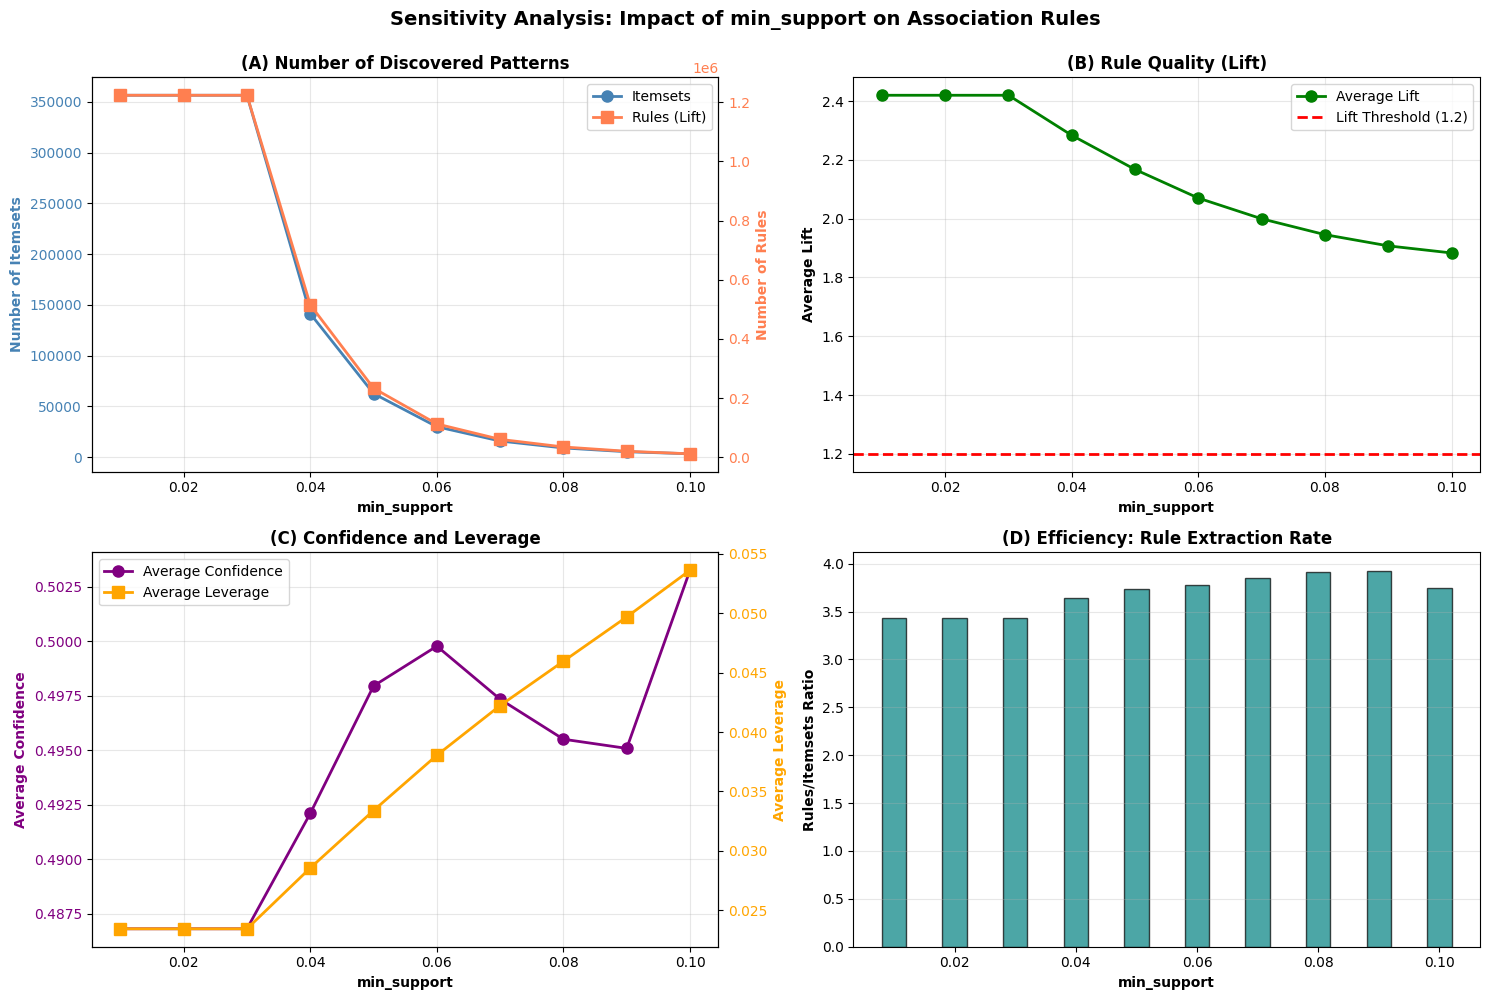


Sensitivity chart saved as: sensitivity_analysis.png


In [58]:
# Visualization of Sensitivity Analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Sensitivity Analysis: Impact of min_support on Association Rules', 
             fontsize=14, fontweight='bold', y=0.995)

# Plot 1: Number of Itemsets and Rules vs min_support
ax1 = axes[0, 0]
ax1_twin = ax1.twinx()

line1 = ax1.plot(sensitivity_df['min_support'], sensitivity_df['n_itemsets'], 
                 'o-', color='steelblue', linewidth=2, markersize=8, label='Itemsets')
line2 = ax1_twin.plot(sensitivity_df['min_support'], sensitivity_df['n_rules_after_lift'], 
                      's-', color='coral', linewidth=2, markersize=8, label='Rules (Lift)')

ax1.set_xlabel('min_support', fontweight='bold')
ax1.set_ylabel('Number of Itemsets', color='steelblue', fontweight='bold')
ax1_twin.set_ylabel('Number of Rules', color='coral', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1_twin.tick_params(axis='y', labelcolor='coral')
ax1.grid(True, alpha=0.3)
ax1.set_title('(A) Number of Discovered Patterns', fontweight='bold')

# Combine legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

# Plot 2: Average Lift and Confidence vs min_support
ax2 = axes[0, 1]
ax2.plot(sensitivity_df['min_support'], sensitivity_df['avg_lift'], 
         'o-', color='green', linewidth=2, markersize=8, label='Average Lift')
ax2.axhline(y=chosen_min_lift, color='red', linestyle='--', linewidth=2, label=f'Lift Threshold ({chosen_min_lift})')
ax2.set_xlabel('min_support', fontweight='bold')
ax2.set_ylabel('Average Lift', fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_title('(B) Rule Quality (Lift)', fontweight='bold')
ax2.legend()

# Plot 3: Average Confidence and Leverage
ax3 = axes[1, 0]
ax3_twin = ax3.twinx()

line1 = ax3.plot(sensitivity_df['min_support'], sensitivity_df['avg_confidence'], 
                 'o-', color='purple', linewidth=2, markersize=8, label='Average Confidence')
line2 = ax3_twin.plot(sensitivity_df['min_support'], sensitivity_df['avg_leverage'], 
                      's-', color='orange', linewidth=2, markersize=8, label='Average Leverage')

ax3.set_xlabel('min_support', fontweight='bold')
ax3.set_ylabel('Average Confidence', color='purple', fontweight='bold')
ax3_twin.set_ylabel('Average Leverage', color='orange', fontweight='bold')
ax3.tick_params(axis='y', labelcolor='purple')
ax3_twin.tick_params(axis='y', labelcolor='orange')
ax3.grid(True, alpha=0.3)
ax3.set_title('(C) Confidence and Leverage', fontweight='bold')

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax3.legend(lines, labels, loc='best')

# Plot 4: Ratio of Rules vs Itemsets
ax4 = axes[1, 1]
rule_itemset_ratio = np.divide(sensitivity_df['n_rules_after_lift'], 
                               sensitivity_df['n_itemsets'], 
                               where=sensitivity_df['n_itemsets']>0, 
                               out=np.zeros_like(sensitivity_df['n_itemsets'], dtype=float))
ax4.bar(sensitivity_df['min_support'], rule_itemset_ratio, width=0.004, color='teal', alpha=0.7, edgecolor='black')
ax4.set_xlabel('min_support', fontweight='bold')
ax4.set_ylabel('Rules/Itemsets Ratio', fontweight='bold')
ax4.set_title('(D) Efficiency: Rule Extraction Rate', fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f"{output_path}/sensitivity_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

print("\nSensitivity chart saved as: sensitivity_analysis.png")

The sensibility analisys first shows that the min_support variation from 0.01 to 0.03 doens't change the number of itemsets and rules. Its is possible to observe that this is stable region, that indicates a high density of patterns with a relative low support. After 0.03 the number of itemsets and rules start to drop significatively, indicating that we are leaving the stable region and entering a more sparse region of the pattern space, then less frequent patterns are being filtered out, only the most common patterns remain. This is reflected in the average lift, which tends to be higher in the stable region (0.01 to 0.03) where more patterns are discovered, while it may decrease as support increases and fewer patterns are retained. Increases support doesn't necessarily improve the lift, this is because rules with a lower support tend to have more strong correlations, rules with a high suppot tend to be more general and less surprising, then they have a lower lift.


In [59]:
# # Comparative Analysis and Insights
# print("\n" + "=" * 100)
# print("COMPARATIVE ANALYSIS - SENSITIVITY INSIGHTS")
# print("=" * 100)

# # Find optimal points
# optimal_support_idx = sensitivity_df['avg_lift'].idxmax()
# optimal_support_value = sensitivity_df.loc[optimal_support_idx, 'min_support']
# optimal_lift = sensitivity_df.loc[optimal_support_idx, 'avg_lift']

# rules_diversity_idx = sensitivity_df['n_rules_after_lift'].idxmax()
# support_max_rules = sensitivity_df.loc[rules_diversity_idx, 'min_support']
# max_rules = sensitivity_df.loc[rules_diversity_idx, 'n_rules_after_lift']

# print(f"\n1. OPTIMAL QUALITY POINT (Highest Average Lift):")
# print(f"   - min_support: {optimal_support_value:.3f}")
# print(f"   - Average lift: {optimal_lift:.4f}")
# print(f"   - Number of rules: {sensitivity_df.loc[optimal_support_idx, 'n_rules_after_lift']:.0f}")

# print(f"\n2. MAXIMUM DISCOVERY POINT (Most Rules):")
# print(f"   - min_support: {support_max_rules:.3f}")
# print(f"   - Number of rules: {max_rules:.0f}")
# print(f"   - Average lift: {sensitivity_df.loc[rules_diversity_idx, 'avg_lift']:.4f}")

# # Compare current choice with others
# current_row = sensitivity_df[sensitivity_df['min_support'] == chosen_min_support].iloc[0]
# print(f"\n3. CURRENT CONFIGURATION (min_support = {chosen_min_support}):")
# print(f"   - Frequent itemsets: {current_row['n_itemsets']:.0f}")
# print(f"   - Extracted rules: {current_row['n_rules_after_lift']:.0f}")
# print(f"   - Average lift: {current_row['avg_lift']:.4f}")
# print(f"   - Average confidence: {current_row['avg_confidence']:.4f}")

# # Calculate trade-offs
# print(f"\n4. TRADE-OFF ANALYSIS:")
# lower_support = sensitivity_df[sensitivity_df['min_support'] < chosen_min_support]
# if len(lower_support) > 0:
#     avg_increase_lower = ((lower_support['n_rules_after_lift'].mean() / current_row['n_rules_after_lift']) - 1) * 100
#     avg_decrease_lift_lower = ((current_row['avg_lift'] / lower_support['avg_lift'].mean()) - 1) * 100
#     print(f"   - Decreasing min_support (average of lower values):")
#     print(f"     • Rule increase: +{avg_increase_lower:.1f}%")
#     print(f"     • Lift reduction: -{avg_decrease_lift_lower:.1f}%")

# higher_support = sensitivity_df[sensitivity_df['min_support'] > chosen_min_support]
# if len(higher_support) > 0:
#     avg_decrease_higher = ((1 - higher_support['n_rules_after_lift'].mean() / current_row['n_rules_after_lift']) * 100)
#     avg_increase_lift_higher = ((higher_support['avg_lift'].mean() / current_row['avg_lift']) - 1) * 100
#     print(f"   - Increasing min_support (average of higher values):")
#     print(f"     • Rule reduction: -{avg_decrease_higher:.1f}%")
#     print(f"     • Lift increase: +{avg_increase_lift_higher:.1f}%")

# # Recommendation
# print(f"\n5. RECOMMENDATION:")
# if current_row['avg_lift'] > sensitivity_df['avg_lift'].quantile(0.75):
#     print(f"   ✓ Current configuration ({chosen_min_support}) is HIGH QUALITY")
#     print(f"     → Positioned in the upper lift quartile (Q75+)")
#     print(f"     → Maintains a good balance between discovery and reliability")
# else:
#     print(f"   ⚠ Consider adjusting for better rule quality")
    
# print("\n" + "=" * 100)

# # Create summary table for export
# sensitivity_summary = sensitivity_df[['min_support', 'n_itemsets', 'n_rules_after_lift', 
#                                        'avg_lift', 'avg_confidence', 'avg_leverage']].round(4)
# sensitivity_summary.to_csv(f"{output_path}/sensitivity_analysis_summary.csv", index=False)
# print(f"✓ Sensitivity summary table exported: sensitivity_analysis_summary.csv")